# SPY Distribution

Sea $S_t$ el precio del activo a tiempo $t$. Definimos entonces el retorno logarítmico a tiempo $t$ como:

$$x_t = \log S_t - \log S_{t-1}$$.

Se puede observar que la distribución de los retornos logarítmicos es altamente leptokúrtica, es decir, los.

[*********************100%***********************]  1 of 1 completed


Normal: μ=0.0004, σ=0.0117
t-Student: df=2.7365, loc=0.0008, scale=0.0069
Kurtosis (Excess): 11.3970 (Normal = 0.0)
Skewness: -0.2485 (Normal = 0.0)


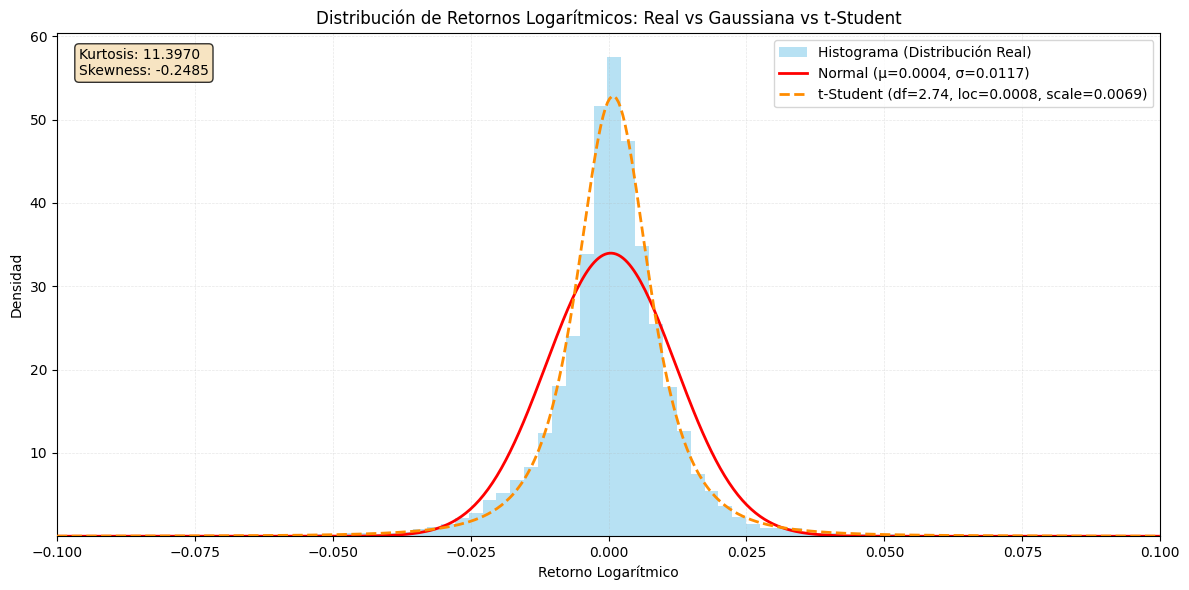

In [20]:

import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import scipy.stats as stats
from scipy.stats import gaussian_kde

# Download and process data
data = yf.download('SPY', start='1990-01-01', end='2026-01-01', auto_adjust=False)
log_ret = np.log(data['Adj Close'] / data['Adj Close'].shift(1)).dropna().values.flatten()

# Setup x-axis range for plotting
x = np.linspace(-0.1, 0.1, 500)

# Empirical density estimation using KDE
kde = gaussian_kde(log_ret, bw_method='scott')
empirical_density = kde(x)

# Fit Normal distribution
mu, std = stats.norm.fit(log_ret)
normal_density = stats.norm.pdf(x, mu, std)

# Fit t-Student distribution
df_t, loc_t, scale_t = stats.t.fit(log_ret)
t_density = stats.t.pdf(x, df_t, loc_t, scale_t)

# Calculate kurtosis and skewness
kurtosis = stats.kurtosis(log_ret)
skewness = stats.skew(log_ret)

print(f"Normal: μ={mu:.4f}, σ={std:.4f}")
print(f"t-Student: df={df_t:.4f}, loc={loc_t:.4f}, scale={scale_t:.4f}")
print(f"Kurtosis (Excess): {kurtosis:.4f} (Normal = 0.0)")
print(f"Skewness: {skewness:.4f} (Normal = 0.0)")

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))

# Plot histogram (real distribution using bins)
ax.hist(log_ret, bins=100, density=True, alpha=0.6, color='skyblue', 
        label='Histograma (Distribución Real)', zorder=1)

# Plot KDE approximation
# ax.plot(x, empirical_density, color='green', linewidth=2, 
#         label='KDE (Aproximación Empírica)', zorder=3)

# Plot Gaussian fit
ax.plot(x, normal_density, 'r-', linewidth=2, 
        label=f'Normal (μ={mu:.4f}, σ={std:.4f})', zorder=2)

# Plot t-Student fit
ax.plot(x, t_density, color='darkorange', linewidth=2, linestyle='--',
        label=f't-Student (df={df_t:.2f}, loc={loc_t:.4f}, scale={scale_t:.4f})', zorder=4)

# ax.set_yscale('log')
# ax.set_xscale('log')
ax.set_xlim(-0.1, 0.1)
ax.set_ylim(bottom=1e-3)
ax.set_xlabel('Retorno Logarítmico')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de Retornos Logarítmicos: Real vs Gaussiana vs t-Student')

# Add text box with kurtosis and skewness
textstr = f'Kurtosis: {kurtosis:.4f}\nSkewness: {skewness:.4f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.97, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

ax.legend(loc='best')
ax.grid(True, alpha=0.3, which="both", linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()


[*********************100%***********************]  1 of 1 completed


Normal: μ=0.0004, σ=0.0117
Kurtosis (Excess): 11.3970 (Normal = 0.0)
Skewness: -0.2485 (Normal = 0.0)


C:\Users\migue\AppData\Local\Temp\ipykernel_17640\3132378609.py:51: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(-0.1, 0.1)


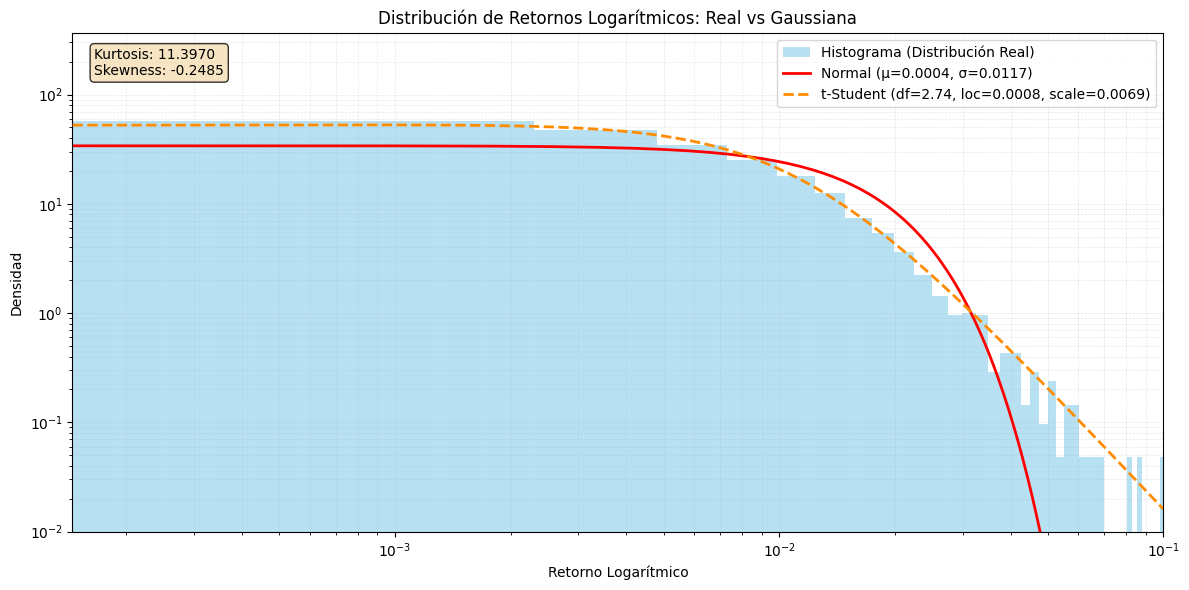

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import scipy.stats as stats
from scipy.stats import gaussian_kde

# Download and process data
data = yf.download('SPY', start='1990-01-01', end='2026-01-01', auto_adjust=False)
log_ret = np.log(data['Adj Close'] / data['Adj Close'].shift(1)).dropna().values.flatten()

# Setup x-axis range for plotting
x = np.linspace(-0.1, 0.1, 500)

# Empirical density estimation using KDE
kde = gaussian_kde(log_ret, bw_method='scott')
empirical_density = kde(x)

# Fit Normal distribution
mu, std = stats.norm.fit(log_ret)
normal_density = stats.norm.pdf(x, mu, std)

# Calculate kurtosis and skewness
kurtosis = stats.kurtosis(log_ret)
skewness = stats.skew(log_ret)

print(f"Normal: μ={mu:.4f}, σ={std:.4f}")
print(f"Kurtosis (Excess): {kurtosis:.4f} (Normal = 0.0)")
print(f"Skewness: {skewness:.4f} (Normal = 0.0)")

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))

# Plot histogram (real distribution using bins)
ax.hist(log_ret, bins=100, density=True, alpha=0.6, color='skyblue', 
        label='Histograma (Distribución Real)', zorder=1)

# Plot KDE approximation
# ax.plot(x, empirical_density, color='green', linewidth=2, 
#         label='KDE (Aproximación Empírica)', zorder=3)

# Plot Gaussian fit
ax.plot(x, normal_density, 'r-', linewidth=2, 
        label=f'Normal (μ={mu:.4f}, σ={std:.4f})', zorder=2)

# Plot t-Student fit
ax.plot(x, t_density, color='darkorange', linewidth=2, linestyle='--',
        label=f't-Student (df={df_t:.2f}, loc={loc_t:.4f}, scale={scale_t:.4f})', zorder=4)

ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlim(-0.1, 0.1)
ax.set_ylim(bottom=1e-2)
ax.set_xlabel('Retorno Logarítmico')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de Retornos Logarítmicos: Real vs Gaussiana')

# Add text box with kurtosis and skewness
textstr = f'Kurtosis: {kurtosis:.4f}\nSkewness: {skewness:.4f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.97, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

ax.legend(loc='best')
ax.grid(True, alpha=0.3, which="both", linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

[*********************100%***********************]  1 of 1 completed


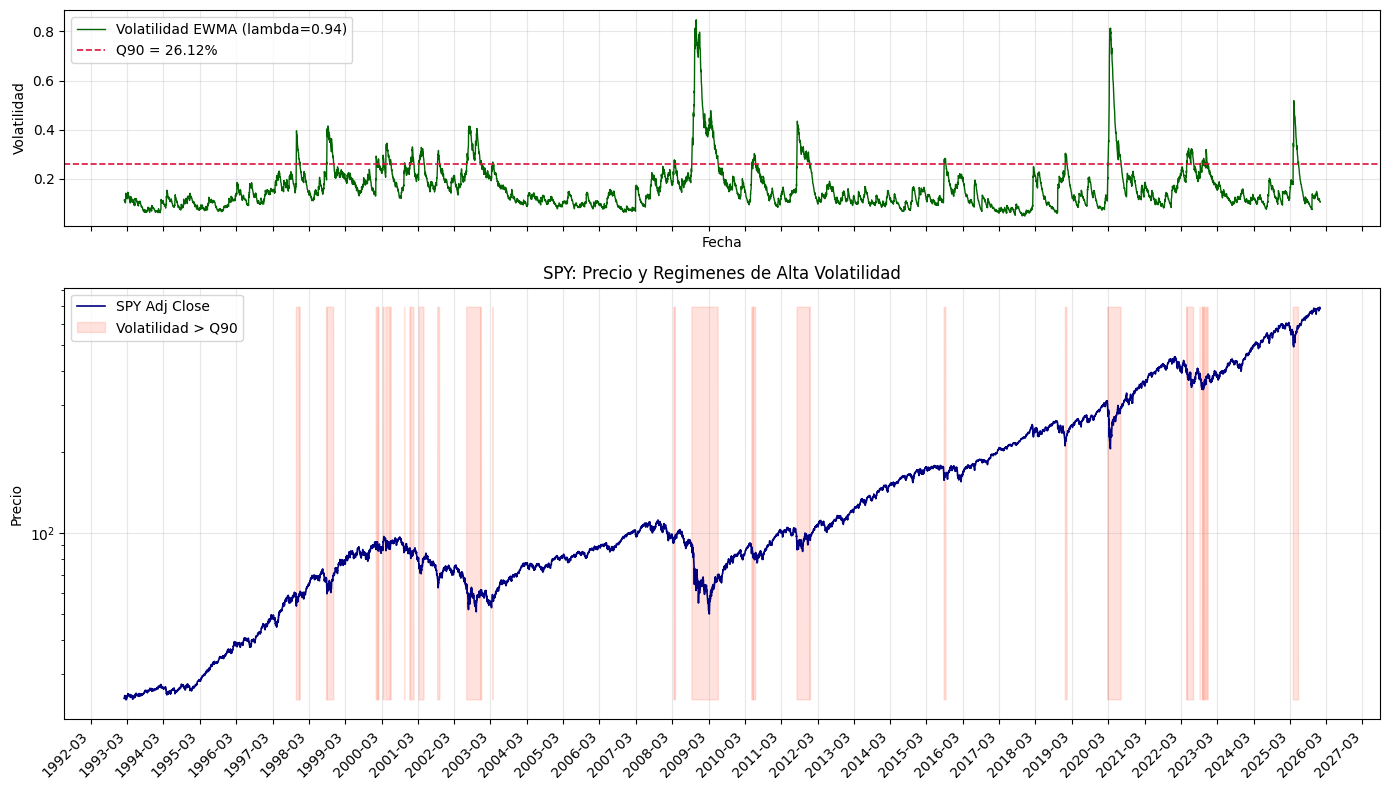

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

# Descarga de datos de SPY
data = yf.download('SPY', start='1990-01-01', end='2026-01-01', auto_adjust=False)
close = data['Adj Close'].dropna().squeeze()

# Volatilidad anualizada usando EWMA
log_returns = np.log(close / close.shift(1))
lambda_ewma = 0.94
ewma_variance = log_returns.pow(2).ewm(alpha=1 - lambda_ewma, adjust=False).mean()
volatility = np.sqrt(ewma_variance) * np.sqrt(252)

# Umbral del percentil 90
vol_q90 = volatility.quantile(0.90)
high_vol_mask = (volatility > vol_q90).reindex(close.index).fillna(False)

# Subplots: precio y volatilidad
fig, (ax_vol, ax_price) = plt.subplots(
    2, 1, figsize=(14, 8), sharex=True, gridspec_kw={'height_ratios': [1, 2]}
)

# Volatilidad
ax_vol.plot(volatility.index, volatility, color='darkgreen', linewidth=1.0, label=f'Volatilidad EWMA (lambda={lambda_ewma:.2f})')
ax_vol.axhline(vol_q90, color='crimson', linestyle='--', linewidth=1.2, label=f'Q90 = {vol_q90:.2%}')
ax_vol.set_xlabel('Fecha')
ax_vol.set_ylabel('Volatilidad')
ax_vol.grid(alpha=0.3)
ax_vol.legend(loc='upper left')

# Precio del SPY
ax_price.semilogy(close.index, close, color='navy', linewidth=1.2, label='SPY Adj Close')
ax_price.fill_between(
    close.index,
    close.min(),
    close.max(),
    where=high_vol_mask.values,
    color='tomato',
    alpha=0.18,
    interpolate=True,
    label='Volatilidad > Q90'
)
ax_price.set_title('SPY: Precio y Regimenes de Alta Volatilidad')
ax_price.set_ylabel('Precio')
ax_price.grid(alpha=0.3)
ax_price.legend(loc='upper left')
import matplotlib.dates as mdates

# Mayor densidad de etiquetas en el eje X (cada 12 meses)
ax_price.xaxis.set_major_locator(mdates.MonthLocator(interval=12))
ax_price.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# # Opcional: marcas menores mensuales para mas detalle visual
# ax_price.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))

plt.setp(ax_price.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()